# Black–Scholes with classical Brownian motion and with $G$-Brownian motion

Chapters 3 and 4 of the thesis price HDD options in a normal (Bachelier-type) model, first with a classical
Brownian motion and then with a $G$-Brownian motion, where the $G$-normal variance interval
$[\underline\sigma^2,\bar\sigma^2]$ turns the single price into an upper and a lower price. This notebook does the
same exercise for European calls and puts in the Black–Scholes model.

## The two models

**Classical.** Under the risk-neutral measure $dS_t = rS_t\,dt + \sigma S_t\,dW_t$ with $W$ a standard Brownian
motion. The price $u(t,S)$ of a payoff $\varphi(S_T)$ solves the Black–Scholes equation

$$\partial_t u + rS\,\partial_S u + \tfrac12\sigma^2 S^2\,\partial_{SS}u - ru = 0,\qquad u(T,S)=\varphi(S),$$

and for a call and a put this gives the closed forms
$C = S\Phi(d_1)-Ke^{-rT}\Phi(d_2)$, $P = Ke^{-rT}\Phi(-d_2)-S\Phi(-d_1)$ with
$d_{1,2} = \bigl[\ln(S/K)+(r\pm\sigma^2/2)T\bigr]/(\sigma\sqrt T)$.

**$G$-Brownian.** Replace $W$ by a $G$-Brownian motion $B$ with $\underline\sigma^2 = -\hat{\mathbb E}[-B_1^2]$ and
$\bar\sigma^2=\hat{\mathbb E}[B_1^2]$, so $dS_t = rS_t\,dt + S_t\,dB_t$ and the volatility is only known to lie
in $[\underline\sigma,\bar\sigma]$. The sublinear expectation is not additive, so a payoff has an **upper price**
$\bar u = e^{-rT}\hat{\mathbb E}[\varphi(S_T)]$ and a **lower price** $\underline u = -e^{-rT}\hat{\mathbb E}[-\varphi(S_T)]$.
By the nonlinear Feynman–Kac formula the upper price solves the Black–Scholes–Barenblatt equation

$$\partial_t \bar u + rS\,\partial_S \bar u + G\!\left(S^2\partial_{SS}\bar u\right) - r\bar u = 0,\qquad
G(\alpha)=\tfrac12\bigl(\bar\sigma^2\alpha^+ - \underline\sigma^2\alpha^-\bigr),$$

which is the $G$-heat equation (2.6)–(2.9) of the thesis with the Black–Scholes drift added. The lower price
solves the same equation with $\underline\sigma$ and $\bar\sigma$ interchanged. Exactly as in the thesis's
Cases 1 and 2 (equations 2.11–2.14): if the payoff is **convex**, $\partial_{SS}\bar u\ge0$ everywhere, the
nonlinearity never switches, and the upper price is the classical Black–Scholes price at $\bar\sigma$ while the
lower price is the classical price at $\underline\sigma$. For payoffs that are neither convex nor concave the
equation genuinely switches between the two volatilities and has to be solved numerically.

The upper price is also $\sup_{\mathbb P}$ of the classical price over all volatility processes
$\sigma_t\in[\underline\sigma,\bar\sigma]$ adapted to the filtration, which is how it is checked by simulation
below: the worst case chooses $\bar\sigma$ wherever the option's gamma is positive and $\underline\sigma$ where it
is negative.

## What is compared

1. Closed-form classical prices against the classical-Brownian Monte Carlo.
2. The $G$ upper and lower prices from the Black–Scholes–Barenblatt solver against their closed forms.
3. Calls and puts across strikes: the classical price sits inside the $G$ interval; how wide the interval is,
   and how the width scales with the volatility uncertainty and with vega.
4. Put–call parity under the sublinear expectation: it holds for the *pair* but not for the *sum* of separately
   priced legs, which produces a bid–ask spread from volatility uncertainty alone.
5. Non-convex payoffs (a bull call spread and a butterfly), where the $G$ interval is strictly wider than
   anything a constant volatility in $[\underline\sigma,\bar\sigma]$ can produce.
6. The thesis's own normal model: the HDD call/put formulas (3.22)/(3.24) and their $G$ versions, side by side
   with the Black–Scholes case.

In [1]:
%matplotlib inline
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "legend.frameon": False})
# fixed categorical roles: classical = blue, G upper = orange, G lower = aqua, reference = gray
C_BS, C_UP, C_LO, C_REF, C_MC = "#2a78d6", "#eb6834", "#1baf7a", "#6b6b6b", "#e87ba4"

In [2]:
# -----------------------------
# Settings -- the only place these live
# -----------------------------
S0     = 100.0
r      = 0.05
T      = 1.0
sigma  = 0.20                 # classical volatility
s_lo, s_hi = 0.15, 0.25       # G-Brownian volatility interval, centred on sigma
K_GRID = np.arange(60.0, 141.0, 5.0)
SEED   = 2020

print("S0 = {:g}, r = {:g}, T = {:g}".format(S0, r, T))
print("classical sigma = {:g};  G interval [{:g}, {:g}]".format(sigma, s_lo, s_hi))

S0 = 100, r = 0.05, T = 1
classical sigma = 0.2;  G interval [0.15, 0.25]


## 1. Classical Black–Scholes: closed form and classical Brownian Monte Carlo

In [3]:
def bs_price(S, K, r, T, sig, kind="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sig ** 2) * T) / (sig * np.sqrt(T))
    d2 = d1 - sig * np.sqrt(T)
    if kind == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def bs_vega(S, K, r, T, sig):
    d1 = (np.log(S / K) + (r + 0.5 * sig ** 2) * T) / (sig * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)


def mc_classical(K, sig, n_paths=2_000_000, seed=SEED):
    # S_T under GBM is lognormal, so one draw of W_T suffices for a European payoff
    rng = np.random.default_rng(seed)
    W = rng.standard_normal(n_paths) * np.sqrt(T)
    ST = S0 * np.exp((r - 0.5 * sig ** 2) * T + sig * W)
    out = {}
    for kind, pay in [("call", np.maximum(ST - K, 0)), ("put", np.maximum(K - ST, 0))]:
        disc = np.exp(-r * T) * pay
        out[kind] = (disc.mean(), 1.96 * disc.std() / np.sqrt(n_paths))
    return out


rows = []
for K in (80.0, 100.0, 120.0):
    mc = mc_classical(K, sigma)
    for kind in ("call", "put"):
        rows.append({"K": K, "option": kind,
                     "closed form": round(bs_price(S0, K, r, T, sigma, kind), 4),
                     "Monte Carlo": "{:.4f} ± {:.4f}".format(*mc[kind])})
pd.DataFrame(rows).set_index(["K", "option"])

closed form       Monte Carlo
K     option                               
80.0  call        24.5888  24.5720 ± 0.0265
      put          0.6872   0.6911 ± 0.0037
100.0 call        10.4506  10.4342 ± 0.0204
      put          5.5735   5.5779 ± 0.0120
120.0 call         3.2475   3.2402 ± 0.0120
      put         17.3950  17.4084 ± 0.0206

## 2. The $G$-Black–Scholes prices: the Black–Scholes–Barenblatt solver

In $x=\ln S$ the equation for the time-to-maturity function $v(\tau,x)$ reads

$$\partial_\tau v = \tfrac12\,\sigma^2(\Gamma)\,\Gamma + r\,\partial_x v - rv,\qquad
\Gamma := \partial_{xx}v - \partial_x v = S^2\partial_{SS}u,$$

with $\sigma^2(\Gamma)=\bar\sigma^2$ if $\Gamma\ge0$ and $\underline\sigma^2$ otherwise for the upper price, and the
reverse for the lower price. An explicit finite-difference scheme is enough here: the grid is fine, the run is
a second per option, and the scheme is validated against the closed form for convex payoffs. The far
boundaries are set to the discounted payoff of the forward, exact for the flat or linear tails of every payoff
used. The solver also returns the worst-case volatility field $\sigma^*(t,S)$, which is what the simulation
check in Section 5 needs.

In [4]:
def bsb_solve(payoff, s_lo, s_hi, upper=True, Nx=1201, half_width=None, keep_policy=False):
    # Explicit scheme in x = ln S on [ln S0 - L, ln S0 + L]; returns price at S0 and (optionally)
    # the worst-case sigma field on the (time, x) grid.
    L = half_width or (6.0 * s_hi * np.sqrt(T) + abs(r) * T)
    x = np.linspace(np.log(S0) - L, np.log(S0) + L, Nx)
    dx = x[1] - x[0]
    S = np.exp(x)
    dt = 0.4 * dx ** 2 / s_hi ** 2
    Nt = int(np.ceil(T / dt)); dt = T / Nt
    hi2, lo2 = (s_hi ** 2, s_lo ** 2) if upper else (s_lo ** 2, s_hi ** 2)
    v = payoff(S).astype(float)
    policy = np.zeros((Nt, Nx), dtype=bool) if keep_policy else None
    for n in range(Nt):
        tau = (n + 1) * dt
        vx = (v[2:] - v[:-2]) / (2 * dx)
        vxx = (v[2:] - 2 * v[1:-1] + v[:-2]) / dx ** 2
        gamma = vxx - vx
        use_hi = gamma >= 0
        sig2 = np.where(use_hi, hi2, lo2)
        new = v.copy()
        new[1:-1] = v[1:-1] + dt * (0.5 * sig2 * gamma + r * vx - r * v[1:-1])
        new[0], new[-1] = np.exp(-r * tau) * payoff(S[[0, -1]] * np.exp(r * tau))
        v = new
        if keep_policy:
            policy[n, 1:-1] = use_hi
            policy[n, [0, -1]] = policy[n, [1, -2]]
    price = float(np.interp(np.log(S0), x, v))
    if keep_policy:
        # policy[n] is the choice made at time-to-maturity (n+1) dt, i.e. calendar time T - (n+1) dt
        return price, {"x": x, "S": S, "dt": dt, "Nt": Nt, "policy": policy,
                       "hi": s_hi if upper else s_lo, "lo": s_lo if upper else s_hi}
    return price


def G_interval(payoff, s_lo, s_hi, **kw):
    return bsb_solve(payoff, s_lo, s_hi, upper=False, **kw), bsb_solve(payoff, s_lo, s_hi, upper=True, **kw)


call = lambda K: (lambda S: np.maximum(S - K, 0.0))
put  = lambda K: (lambda S: np.maximum(K - S, 0.0))

rows = []
t0 = time.time()
for K in (80.0, 100.0, 120.0):
    for kind, pay in (("call", call(K)), ("put", put(K))):
        lo, hi = G_interval(pay, s_lo, s_hi)
        rows.append({"K": K, "option": kind,
                     "G lower (PDE)": round(lo, 4), "closed form at sigma_lo": round(bs_price(S0, K, r, T, s_lo, kind), 4),
                     "G upper (PDE)": round(hi, 4), "closed form at sigma_hi": round(bs_price(S0, K, r, T, s_hi, kind), 4)})
df = pd.DataFrame(rows).set_index(["K", "option"])
df["max |error|"] = np.maximum((df["G lower (PDE)"] - df["closed form at sigma_lo"]).abs(),
                              (df["G upper (PDE)"] - df["closed form at sigma_hi"]).abs()).round(4)
print("{} PDE solves in {:.1f}s".format(2 * len(rows), time.time() - t0))
df

12 PDE solves in 12.0s


G lower (PDE)  closed form at sigma_lo  G upper (PDE)  \
K     option                                                          
80.0  call          24.0785                  24.0784        25.4125   
      put            0.1768                   0.1768         1.5109   
100.0 call           8.5915                   8.5917        12.3359   
      put            3.7144                   3.7146         7.4589   
120.0 call           1.6601                   1.6600         5.0255   
      put           15.8076                  15.8075        19.1730   

              closed form at sigma_hi  max |error|  
K     option                                        
80.0  call                    25.4125       0.0001  
      put                      1.5109       0.0000  
100.0 call                    12.3360       0.0002  
      put                      7.4589       0.0002  
120.0 call                     5.0254       0.0001  
      put                     19.1729       0.0001

The solver reproduces the closed forms to a few $10^{-3}$, and confirms the thesis's Case 1: for the convex call
and put the Black–Scholes–Barenblatt equation never switches volatility, so
$\bar C = C_{BS}(\bar\sigma)$ and $\underline C = C_{BS}(\underline\sigma)$, and likewise for the put.
From here on the convex payoffs use the closed forms and the PDE is reserved for the non-convex ones.

## 3. Calls and puts across strikes: one price against an interval

In [5]:
tab = pd.DataFrame({"K": K_GRID})
for kind in ("call", "put"):
    tab[kind + " BS"]      = bs_price(S0, K_GRID, r, T, sigma, kind)
    tab[kind + " G lower"] = bs_price(S0, K_GRID, r, T, s_lo, kind)
    tab[kind + " G upper"] = bs_price(S0, K_GRID, r, T, s_hi, kind)
    tab[kind + " width"]   = tab[kind + " G upper"] - tab[kind + " G lower"]
    tab[kind + " width / BS"] = tab[kind + " width"] / tab[kind + " BS"]
tab.set_index("K").round(4)

,call BS,call G lower,call G upper,call width,call width / BS,put BS,put G lower,put G upper,put width,put width / BS
K,,,,,,,,,,
60.0,42.9375,42.9265,43.0073,0.0808,0.0019,0.0113,0.0002,0.0810,0.0808,7.1526
65.0,38.2122,38.1722,38.3734,0.2012,0.0053,0.0421,0.0021,0.2033,0.2012,4.7786
70.0,33.5401,33.4264,33.8565,0.4300,0.0128,0.1262,0.0125,0.4425,0.4300,3.4087
75.0,28.9744,28.7111,29.5153,0.8042,0.0278,0.3166,0.0533,0.8575,0.8042,2.5403
80.0,24.5888,24.0784,25.4125,1.3341,0.0543,0.6872,0.1768,1.5109,1.3341,1.9414
85.0,20.4693,19.6211,21.6057,1.9846,0.0970,1.3238,0.4756,2.4602,1.9846,1.4992
90.0,16.6994,15.4672,18.1408,2.6736,0.1601,2.3101,1.0778,3.7514,2.6736,1.1574
95.0,13.3465,11.7538,15.0471,3.2932,0.2467,3.7133,2.1206,5.4138,3.2932,0.8869
100.0,10.4506,8.5917,12.3360,3.7443,0.3583,5.5735,3.7146,7.4589,3.7443,0.6718


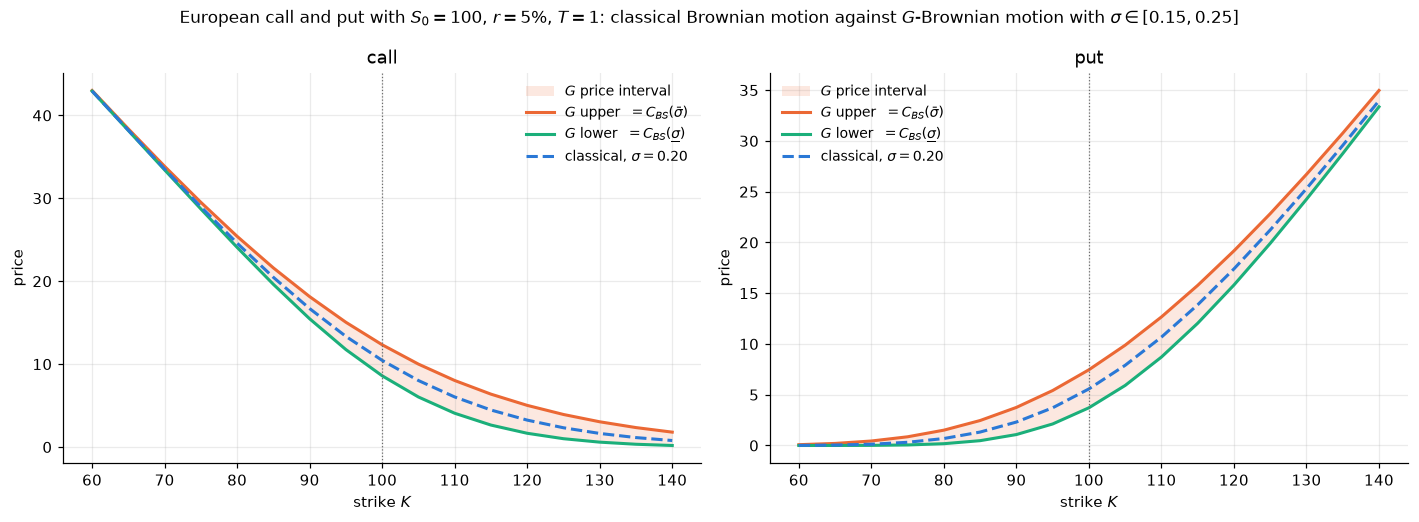

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, kind in zip(axes, ("call", "put")):
    ax.fill_between(K_GRID, tab[kind + " G lower"], tab[kind + " G upper"], color=C_UP, alpha=0.15, linewidth=0,
                    label=r"$G$ price interval")
    ax.plot(K_GRID, tab[kind + " G upper"], color=C_UP, linewidth=2, label=r"$G$ upper  $=C_{BS}(\bar\sigma)$")
    ax.plot(K_GRID, tab[kind + " G lower"], color=C_LO, linewidth=2, label=r"$G$ lower  $=C_{BS}(\underline{\sigma})$")
    ax.plot(K_GRID, tab[kind + " BS"], color=C_BS, linewidth=2, linestyle="--", label=r"classical, $\sigma=0.20$")
    ax.axvline(S0, color=C_REF, linewidth=0.8, linestyle=":")
    ax.set_xlabel("strike $K$"); ax.set_ylabel("price"); ax.set_title(kind)
    ax.legend(fontsize=9)
fig.suptitle(r"European {} with $S_0=100$, $r=5\%$, $T=1$: classical Brownian motion against $G$-Brownian motion "
             r"with $\sigma\in[0.15,0.25]$".format("call and put"), fontsize=11)
plt.tight_layout(); plt.savefig("figures/gbs_prices_vs_strike.pdf", bbox_inches="tight"); plt.show()

The classical price is always inside the interval, and the interval is widest at the money in absolute terms
but explodes *relative* to the price far out of the money, where almost all of the option's value is
volatility.

### How the width scales

For a convex payoff the width is $C_{BS}(\bar\sigma)-C_{BS}(\underline\sigma)\approx \mathrm{vega}\cdot(\bar\sigma-\underline\sigma)$,
so it is the option's vega that converts volatility uncertainty into price uncertainty. Below the interval is
recomputed for several symmetric uncertainty widths around $\sigma=0.20$.

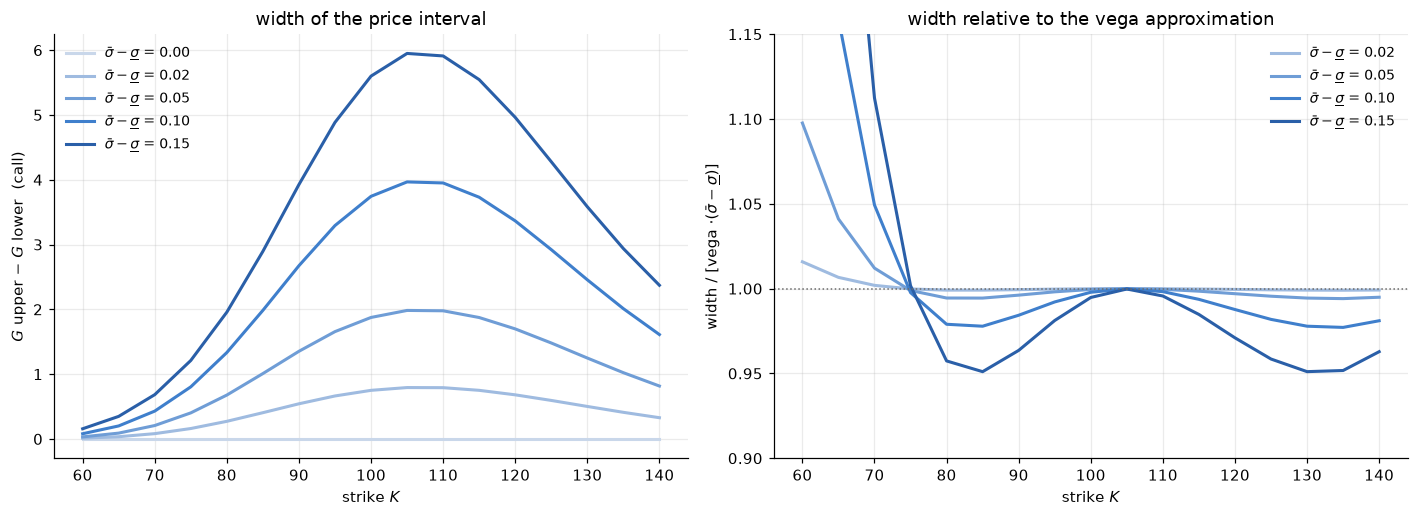

,ATM call width,ATM call BS,K = 120 call width,K = 120 call BS
sigma interval,,,,
"[0.200, 0.200]",0.0000,10.4506,0.0000,3.2475
"[0.190, 0.210]",0.7504,10.4506,0.6812,3.2475
"[0.175, 0.225]",1.8752,10.4506,1.6986,3.2475
"[0.150, 0.250]",3.7443,10.4506,3.3654,3.2475
"[0.125, 0.275]",5.5992,10.4506,4.9628,3.2475


In [7]:
widths = [0.0, 0.02, 0.05, 0.10, 0.15]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
shades = ["#c9d7ea", "#9fbbe0", "#6f9dd6", "#3f7fcc", "#2a5fa8"]     # one hue, light -> dark with width
rows = []
for w, c in zip(widths, shades):
    lo_, hi_ = sigma - w / 2, sigma + w / 2
    width = bs_price(S0, K_GRID, r, T, hi_, "call") - bs_price(S0, K_GRID, r, T, lo_, "call")
    axes[0].plot(K_GRID, width, color=c, linewidth=2, label=r"$\bar\sigma-\underline{{\sigma}}$ = {:.2f}".format(w))
    if w > 0:
        axes[1].plot(K_GRID, width / (w * bs_vega(S0, K_GRID, r, T, sigma)), color=c, linewidth=2,
                     label=r"$\bar\sigma-\underline{{\sigma}}$ = {:.2f}".format(w))
    rows.append({"sigma interval": "[{:.3f}, {:.3f}]".format(lo_, hi_),
                 "ATM call width": round(float(width[K_GRID == 100.0][0]), 4),
                 "ATM call BS": round(float(bs_price(S0, 100.0, r, T, sigma, "call")), 4),
                 "K = 120 call width": round(float(width[K_GRID == 120.0][0]), 4),
                 "K = 120 call BS": round(float(bs_price(S0, 120.0, r, T, sigma, "call")), 4)})
axes[0].set_xlabel("strike $K$"); axes[0].set_ylabel(r"$G$ upper $-$ $G$ lower  (call)")
axes[0].set_title("width of the price interval")
axes[1].axhline(1.0, color=C_REF, linestyle=":", linewidth=1)
axes[1].set_xlabel("strike $K$"); axes[1].set_ylabel(r"width / [vega $\cdot(\bar\sigma-\underline{\sigma})$]")
axes[1].set_title("width relative to the vega approximation")
axes[1].set_ylim(0.9, 1.15)
for ax in axes: ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("figures/gbs_width_scaling.pdf", bbox_inches="tight"); plt.show()
pd.DataFrame(rows).set_index("sigma interval")

The width is linear in $\bar\sigma-\underline\sigma$ to within a few percent at the money, and the ratio to
vega drifts above one in the wings because the call price is convex in $\sigma$ there. Put widths are
identical to call widths at every strike, since put–call parity holds separately at $\underline\sigma$ and at
$\bar\sigma$.

## 4. Put–call parity under a sublinear expectation

Classically $C - P = S_0 - Ke^{-rT}$. Under the $G$-expectation the *pair* $C-P$ has payoff $S_T-K$, which is
linear, so it carries no volatility uncertainty and $\hat{\mathbb E}$ and $-\hat{\mathbb E}[-\,\cdot\,]$ agree on it:
the forward is priced exactly. But $\hat{\mathbb E}$ is only sub-additive,
$\hat{\mathbb E}[X+Y]\le\hat{\mathbb E}[X]+\hat{\mathbb E}[Y]$, so pricing the two legs *separately* and adding
gives $\bar C - \underline P \;\ge\; S_0 - Ke^{-rT}\;\ge\; \underline C - \bar P$. The gap is a bid–ask spread
produced by nothing but volatility uncertainty.

In [8]:
rows = []
for K in (80.0, 100.0, 120.0):
    fwd = S0 - K * np.exp(-r * T)
    C_lo, C_hi = bs_price(S0, K, r, T, s_lo, "call"), bs_price(S0, K, r, T, s_hi, "call")
    P_lo, P_hi = bs_price(S0, K, r, T, s_lo, "put"),  bs_price(S0, K, r, T, s_hi, "put")
    # the pair C - P has linear payoff: solve it in the PDE to show the G price is exact and unique
    pair_lo, pair_hi = G_interval(lambda S, K=K: S - K, s_lo, s_hi)
    rows.append({"K": K, "S0 - K e^{-rT}": round(fwd, 4),
                 "G price of (C - P) as one payoff": "[{:.4f}, {:.4f}]".format(pair_lo, pair_hi),
                 "C_upper - P_lower": round(C_hi - P_lo, 4),
                 "C_lower - P_upper": round(C_lo - P_hi, 4),
                 "bid-ask from uncertainty": round((C_hi - P_lo) - (C_lo - P_hi), 4)})
pd.DataFrame(rows).set_index("K")

,S0 - K e^{-rT},G price of (C - P) as one payoff,C_upper - P_lower,C_lower - P_upper,bid-ask from uncertainty
K,,,,,
80.0,23.9016,"[23.9017, 23.9017]",25.2357,22.5676,2.6682
100.0,4.8771,"[4.8771, 4.8771]",8.6214,1.1327,7.4887
120.0,-14.1475,"[-14.1475, -14.1475]",-10.7821,-17.5129,6.7308


## 5. Non-convex payoffs: where the $G$ price is more than a pair of Black–Scholes prices

A bull call spread $(S_T-K_1)^+-(S_T-K_2)^+$ and a butterfly $(S_T-K_1)^+-2(S_T-K_2)^++(S_T-K_3)^+$ have gamma of
both signs. The worst case for the seller of such an option is not a constant volatility: it is high volatility
where gamma is positive and low volatility where it is negative, switching as the stock moves. So the $G$
upper price exceeds $\max_{\sigma\in[\underline\sigma,\bar\sigma]}C_{BS}(\sigma)$ and the lower price is below the minimum.
This is checked three ways: the Black–Scholes–Barenblatt solver, the envelope of constant-volatility
Black–Scholes prices, and a classical-Brownian Monte Carlo in which the volatility follows the solver's
worst-case field $\sigma^*(t,S)$.

In [9]:
spread    = lambda S: np.maximum(S - 95.0, 0) - np.maximum(S - 105.0, 0)
butterfly = lambda S: np.maximum(S - 90.0, 0) - 2 * np.maximum(S - 100.0, 0) + np.maximum(S - 110.0, 0)
PAYOFFS = {"bull call spread 95/105": spread, "butterfly 90/100/110": butterfly}


def bs_general(payoff, sig, n=400_001):
    # classical price of any European payoff by lognormal quadrature
    z = np.linspace(-8, 8, n)
    ST = S0 * np.exp((r - 0.5 * sig ** 2) * T + sig * np.sqrt(T) * z)
    return np.exp(-r * T) * np.trapezoid(payoff(ST) * norm.pdf(z), z)


def mc_worst_case(payoff, field, n_paths=400_000, n_steps=250, seed=SEED):
    # classical Brownian motion, volatility switched by the solver's worst-case field
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    x = np.full(n_paths, np.log(S0))
    for k in range(n_steps):
        t = k * dt                                             # calendar time; time-to-maturity T - t
        n_idx = min(field["Nt"] - 1, max(0, int(round((T - t) / field["dt"])) - 1))
        j = np.clip(np.searchsorted(field["x"], x), 0, len(field["x"]) - 1)
        sig = np.where(field["policy"][n_idx][j], field["hi"], field["lo"])
        x = x + (r - 0.5 * sig ** 2) * dt + sig * np.sqrt(dt) * rng.standard_normal(n_paths)
    disc = np.exp(-r * T) * payoff(np.exp(x))
    return disc.mean(), 1.96 * disc.std() / np.sqrt(n_paths)


sig_grid = np.linspace(s_lo, s_hi, 41)
rows, FIELDS = [], {}
for name, pay in PAYOFFS.items():
    t0 = time.time()
    lo, fld_lo = bsb_solve(pay, s_lo, s_hi, upper=False, keep_policy=True)
    hi, fld_hi = bsb_solve(pay, s_lo, s_hi, upper=True, keep_policy=True)
    FIELDS[name] = (fld_lo, fld_hi)
    env = np.array([bs_general(pay, s) for s in sig_grid])
    mc_hi = mc_worst_case(pay, fld_hi)
    mc_lo = mc_worst_case(pay, fld_lo)
    rows.append({"payoff": name,
                 "classical BS, sigma = 0.20": round(bs_general(pay, sigma), 4),
                 "min over constant sigma": round(env.min(), 4), "max over constant sigma": round(env.max(), 4),
                 "G lower (PDE)": round(lo, 4), "G upper (PDE)": round(hi, 4),
                 "G lower (worst-case MC)": "{:.4f} ± {:.4f}".format(*mc_lo),
                 "G upper (worst-case MC)": "{:.4f} ± {:.4f}".format(*mc_hi),
                 "extra width beyond constant-sigma envelope": round((hi - lo) - (env.max() - env.min()), 4)})
    print("{:<26} {:.0f}s".format(name, time.time() - t0))
NONCONVEX = pd.DataFrame(rows).set_index("payoff")
NONCONVEX.T

bull call spread 95/105    20s


butterfly 90/100/110       20s


payoff,bull call spread 95/105,butterfly 90/100/110
"classical BS, sigma = 0.20",5.3251,1.8384
min over constant sigma,5.0448,1.4951
max over constant sigma,5.7183,2.3597
G lower (PDE),4.3331,0.8211
G upper (PDE),6.3424,3.2463
G lower (worst-case MC),4.3540 ± 0.0138,0.8324 ± 0.0064
G upper (worst-case MC),6.3491 ± 0.0129,3.2255 ± 0.0110
extra width beyond constant-sigma envelope,1.3358,1.5606


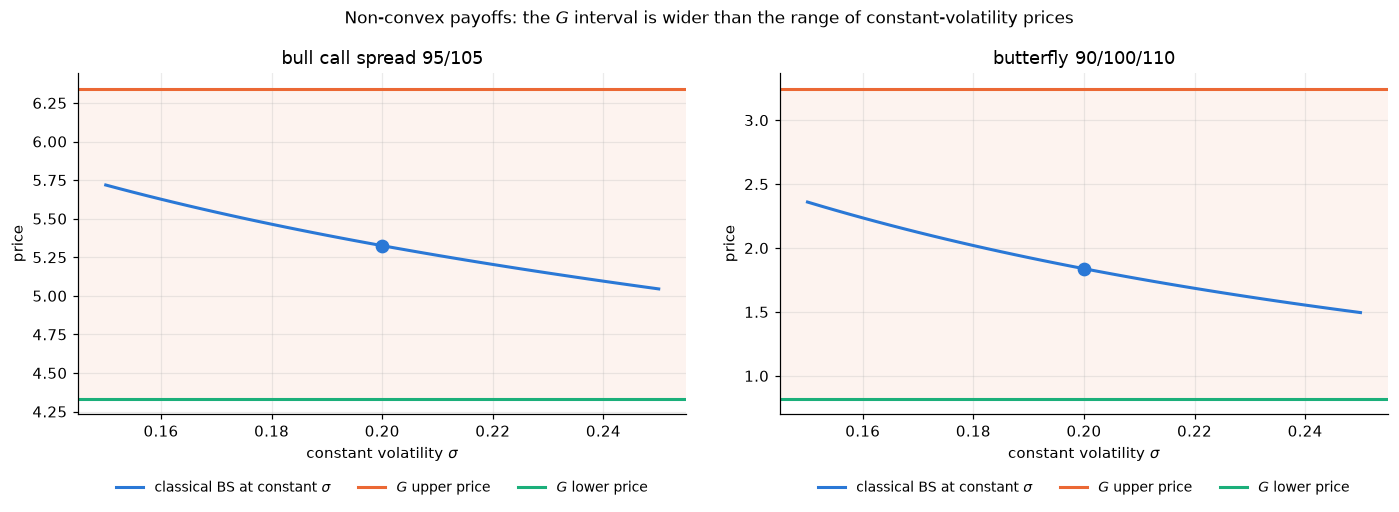

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (name, pay) in zip(axes, PAYOFFS.items()):
    env = np.array([bs_general(pay, s) for s in sig_grid])
    row = NONCONVEX.loc[name]
    ax.plot(sig_grid, env, color=C_BS, linewidth=2, label=r"classical BS at constant $\sigma$")
    ax.axhline(row["G upper (PDE)"], color=C_UP, linewidth=2, label=r"$G$ upper price")
    ax.axhline(row["G lower (PDE)"], color=C_LO, linewidth=2, label=r"$G$ lower price")
    ax.axhspan(row["G lower (PDE)"], row["G upper (PDE)"], color=C_UP, alpha=0.08, linewidth=0)
    ax.plot([sigma], [row["classical BS, sigma = 0.20"]], "o", color=C_BS, markersize=8)
    ax.set_xlabel(r"constant volatility $\sigma$"); ax.set_ylabel("price"); ax.set_title(name)
    ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)
fig.suptitle(r"Non-convex payoffs: the $G$ interval is wider than the range of constant-volatility prices", fontsize=11)
plt.tight_layout(); plt.savefig("figures/gbs_nonconvex.pdf", bbox_inches="tight"); plt.show()

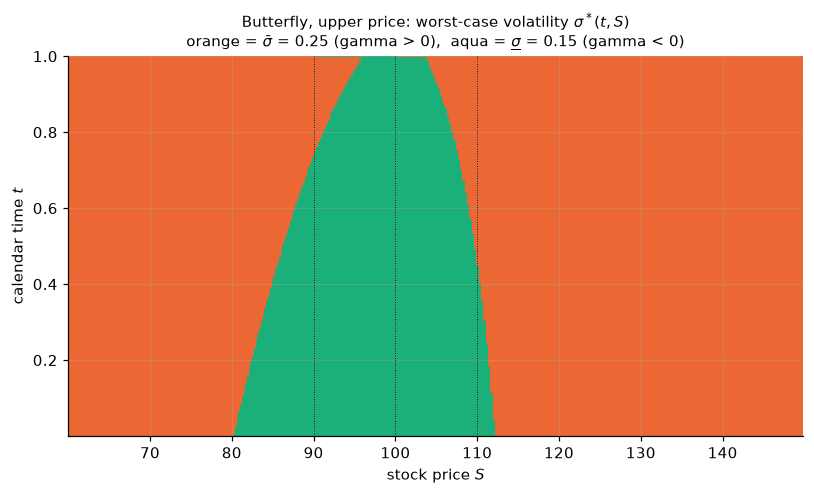

In [11]:
# the worst-case volatility field sigma*(t, S) behind the G upper price of the butterfly
fld = FIELDS["butterfly 90/100/110"][1]
step_t = max(1, fld["Nt"] // 400)
pol = fld["policy"][::step_t]                   # rows: time-to-maturity increasing
tau = (np.arange(fld["Nt"])[::step_t] + 1) * fld["dt"]
mask = (fld["S"] > 60) & (fld["S"] < 150)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
im = ax.pcolormesh(fld["S"][mask], T - tau, np.where(pol[:, mask], fld["hi"], fld["lo"]),
                   cmap=plt.matplotlib.colors.ListedColormap([C_LO, C_UP]), shading="auto")
for K_ in (90, 100, 110): ax.axvline(K_, color="k", linewidth=0.6, linestyle=":")
ax.set_xlabel("stock price $S$"); ax.set_ylabel("calendar time $t$")
ax.set_title(r"Butterfly, upper price: worst-case volatility $\sigma^*(t,S)$"
             "\n" r"orange = $\bar\sigma$ = 0.25 (gamma > 0),  aqua = $\underline{\sigma}$ = 0.15 (gamma < 0)", fontsize=10)
plt.tight_layout(); plt.savefig("figures/gbs_worst_case_field.pdf", bbox_inches="tight"); plt.show()

The Monte Carlo that switches volatility according to $\sigma^*(t,S)$ lands on the solver's price, while no
constant volatility gets there: for the butterfly the $G$ interval is several times wider than the spread of
constant-volatility prices. The plain call and put never show this because their gamma has one sign. This is
the point at which "$G$-Brownian pricing" stops being "Black–Scholes at two volatilities".

## 6. The thesis's normal model, and its $G$ version

Chapter 3 prices the HDD call as $c = e^{-r\tau}\,[(\mu_m-K)\Phi(d)+\sigma_m\varphi(d)]$ with $d=(\mu_m-K)/\sigma_m$,
equation (3.22), and the put by (3.24). This is the Bachelier formula: the index is normal because the
temperature is driven by an *arithmetic* Brownian motion. Under $G$-Brownian motion with $\eta\equiv0$, the
closed-form case of Section 4.3.1, the index is $G$-normal with variance interval
$[\underline\sigma_B^2 V_m,\ \bar\sigma_B^2 V_m]$, and the same convexity argument makes the upper price the
Bachelier price at $\bar\sigma_B\sigma_m$ and the lower price the Bachelier price at $\underline\sigma_B\sigma_m$.

To put both models in one picture the index is given the same forward and the same at-the-money price as the
stock: $\mu_m = S_0e^{rT}$ and $\sigma_m$ chosen so that the classical Bachelier and Black–Scholes at-the-money
calls agree.

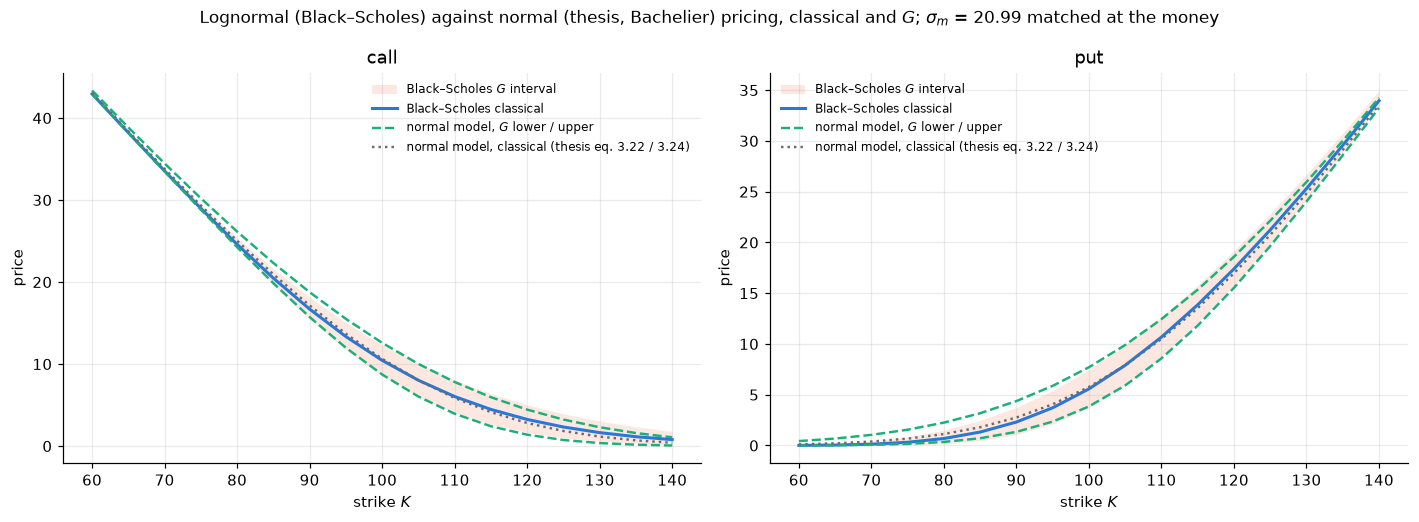

BS classical       BS G interval  normal classical  \
option K                                                           
call   80.0        24.5888  [24.0784, 25.4125]           25.0286   
       100.0       10.4506   [8.5917, 12.3360]           10.6405   
       120.0        3.2475    [1.6600, 5.0254]            2.8117   
put    80.0         0.6872    [0.1768, 1.5109]            1.1269   
       100.0        5.5735    [3.7146, 7.4589]            5.7635   
       120.0       17.3950  [15.8075, 19.1729]           16.9593   

               normal G interval  
option K                          
call   80.0   [24.2529, 26.1542]  
       100.0   [8.7268, 12.5850]  
       120.0    [1.3846, 4.4413]  
put    80.0     [0.3513, 2.2526]  
       100.0    [3.8497, 7.7079]  
       120.0  [15.5321, 18.5889]

In [12]:
def bachelier(mu, K, r, T, s, kind="call"):
    d = (mu - K) / s
    if kind == "call":
        return np.exp(-r * T) * ((mu - K) * norm.cdf(d) + s * norm.pdf(d))
    return np.exp(-r * T) * ((K - mu) * norm.cdf(-d) + s * norm.pdf(d))


mu_m = S0 * np.exp(r * T)
# match the classical ATM call: e^{-rT} sigma_m phi(d) + ... = C_BS(K = mu_m)
from scipy.optimize import brentq
sigma_m = brentq(lambda s: bachelier(mu_m, mu_m, r, T, s) - bs_price(S0, mu_m, r, T, sigma), 1e-3, 200.0)
sB_lo, sB_hi = s_lo / sigma, s_hi / sigma       # same relative uncertainty as the Black-Scholes case

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
rows = []
for ax, kind in zip(axes, ("call", "put")):
    bs_lo, bs_hi = bs_price(S0, K_GRID, r, T, s_lo, kind), bs_price(S0, K_GRID, r, T, s_hi, kind)
    ba_lo, ba_hi = bachelier(mu_m, K_GRID, r, T, sB_lo * sigma_m, kind), bachelier(mu_m, K_GRID, r, T, sB_hi * sigma_m, kind)
    ax.fill_between(K_GRID, bs_lo, bs_hi, color=C_UP, alpha=0.15, linewidth=0, label=r"Black–Scholes $G$ interval")
    ax.plot(K_GRID, bs_price(S0, K_GRID, r, T, sigma, kind), color=C_BS, linewidth=2, label="Black–Scholes classical")
    ax.plot(K_GRID, ba_lo, color=C_LO, linewidth=1.6, linestyle="--", label=r"normal model, $G$ lower / upper")
    ax.plot(K_GRID, ba_hi, color=C_LO, linewidth=1.6, linestyle="--")
    ax.plot(K_GRID, bachelier(mu_m, K_GRID, r, T, sigma_m, kind), color=C_REF, linewidth=1.6, linestyle=":",
            label="normal model, classical (thesis eq. 3.22 / 3.24)")
    ax.set_xlabel("strike $K$"); ax.set_ylabel("price"); ax.set_title(kind); ax.legend(fontsize=8)
    for K in (80.0, 100.0, 120.0):
        i = int(np.where(K_GRID == K)[0][0])
        rows.append({"option": kind, "K": K, "BS classical": round(float(bs_price(S0, K, r, T, sigma, kind)), 4),
                     "BS G interval": "[{:.4f}, {:.4f}]".format(bs_lo[i], bs_hi[i]),
                     "normal classical": round(float(bachelier(mu_m, K, r, T, sigma_m, kind)), 4),
                     "normal G interval": "[{:.4f}, {:.4f}]".format(ba_lo[i], ba_hi[i])})
fig.suptitle(r"Lognormal (Black–Scholes) against normal (thesis, Bachelier) pricing, classical and $G$; "
             r"$\sigma_m$ = {:.2f} matched at the money".format(sigma_m), fontsize=11)
plt.tight_layout(); plt.savefig("figures/gbs_vs_normal_model.pdf", bbox_inches="tight"); plt.show()
pd.DataFrame(rows).set_index(["option", "K"])

## 7. Real data: S&P 500 and the VIX, 2014–2018

Everything above uses a chosen $\sigma$ and a chosen interval. Here both come from data. Two market series are
used, both shipped with the `arch` package and saved under `data/`: daily S&P 500 closes for 1999–2018 and
the daily VIX for 2014–2018. The VIX is the 30-day implied volatility that the CBOE computes from actual SPX
option quotes, so a 30-day at-the-money SPX option's market price is recovered from it through the
Black–Scholes formula, which is how the market itself quotes these options. Option chains strike by strike
are not reachable from this environment, so the comparison is at the money and 30 days out, on every trading
day of 2014–2018, which is 1236 dates.

The three volatilities on each date $t$:

* **classical $\sigma_t$** — the realised volatility of the trailing 252 trading days, the single number a
  Black–Scholes user would plug in;
* **$G$ interval $[\underline\sigma_t,\bar\sigma_t]$** — the range of 21-day realised volatility over the trailing
  252 days, i.e. the volatilities the market has actually produced in the past year; the minimum–maximum
  range is the main case and narrower percentile ranges are reported alongside;
* **market $\sigma^{\mathrm{mkt}}_t$** — the VIX, and **realised $\sigma^{\mathrm{fwd}}_t$** — the volatility
  realised over the next 21 trading days, which is what the option actually lived through.

The risk-free rate is the approximate 3-month T-bill average for each year (0.03%, 0.05%, 0.3%, 0.9%, 1.9%);
at 30 days to maturity the prices are insensitive to it.

In [13]:
spx = pd.read_csv("data/sp500_close_1999_2018.csv", index_col=0, parse_dates=True)["SPX"]
vix = pd.read_csv("data/vix_close_2014_2019.csv", index_col=0, parse_dates=True)["vix"] / 100.0
ret = np.log(spx).diff().dropna()
rv21 = ret.rolling(21).std() * np.sqrt(252)                     # trailing 21-day realised vol
fwd21 = rv21.shift(-21)                                          # realised over the NEXT 21 days
trail = ret.rolling(252).std() * np.sqrt(252)                    # classical: trailing-year vol
RBILL = {2014: 0.0003, 2015: 0.0005, 2016: 0.003, 2017: 0.009, 2018: 0.019}

D = pd.DataFrame({"S": spx, "sig_class": trail, "sig_mkt": vix, "sig_fwd": fwd21,
                  "lo": rv21.rolling(252).min(), "hi": rv21.rolling(252).max()}).dropna()
D = D[(D.index >= "2014-01-01") & (D.index <= "2018-12-31")]
D["r"] = [RBILL[y] for y in D.index.year]
T30 = 30 / 365
atm = lambda sig, kind="call": bs_price(D.S, D.S, D.r, T30, sig, kind) / D.S * 100      # % of spot
D["mkt"], D["classical"], D["G_lo"], D["G_hi"] = atm(D.sig_mkt), atm(D.sig_class), atm(D.lo), atm(D.hi)
D["fwd_fair"] = atm(D.sig_fwd)                                   # what the option was worth ex post
print("{} trading days, {} to {}".format(len(D), D.index[0].date(), D.index[-1].date()))
D[["sig_class", "sig_mkt", "sig_fwd", "lo", "hi"]].describe().loc[["mean", "min", "50%", "max"]].round(3)

1236 trading days, 2014-01-03 to 2018-11-28


,sig_class,sig_mkt,sig_fwd,lo,hi
mean,0.121,0.147,0.118,0.051,0.225
min,0.067,0.091,0.035,0.035,0.101
50%,0.117,0.137,0.101,0.048,0.200
max,0.172,0.407,0.319,0.086,0.319


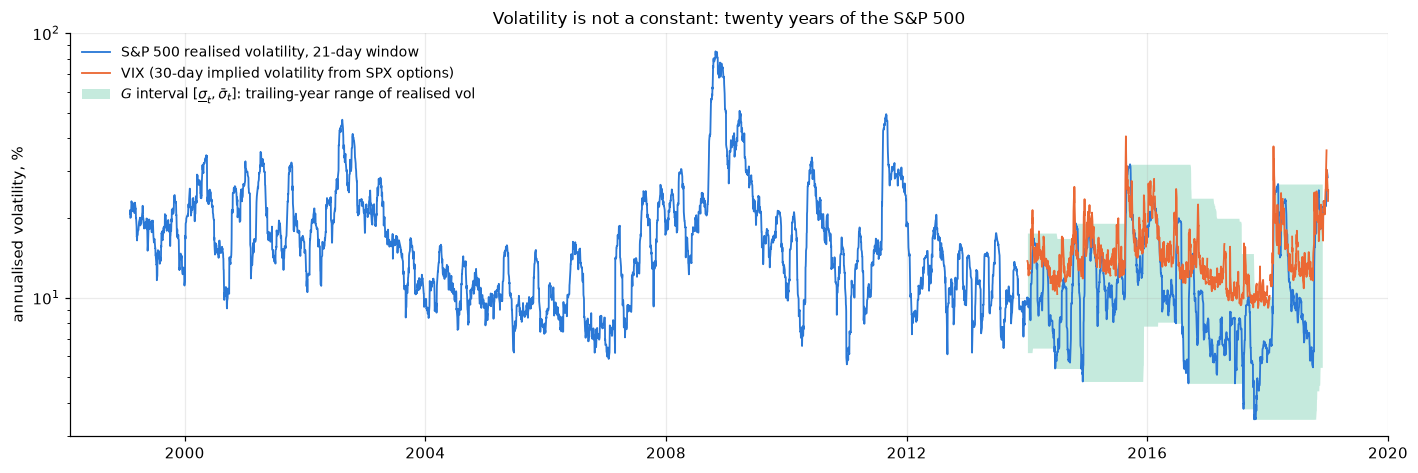

In [14]:
fig, ax = plt.subplots(figsize=(13, 4.4))
ax.plot(rv21.index, rv21 * 100, color=C_BS, linewidth=1.2, label="S&P 500 realised volatility, 21-day window")
ax.plot(vix.index, vix * 100, color=C_UP, linewidth=1.2, label="VIX (30-day implied volatility from SPX options)")
ax.fill_between(D.index, D.lo * 100, D.hi * 100, color=C_LO, alpha=0.25, linewidth=0,
                label=r"$G$ interval $[\underline{\sigma}_t,\bar\sigma_t]$: trailing-year range of realised vol")
ax.set_yscale("log"); ax.set_ylabel("annualised volatility, %"); ax.set_ylim(3, 100)
ax.set_title("Volatility is not a constant: twenty years of the S&P 500", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.savefig("figures/gbs_real_volatility_history.pdf", bbox_inches="tight"); plt.show()

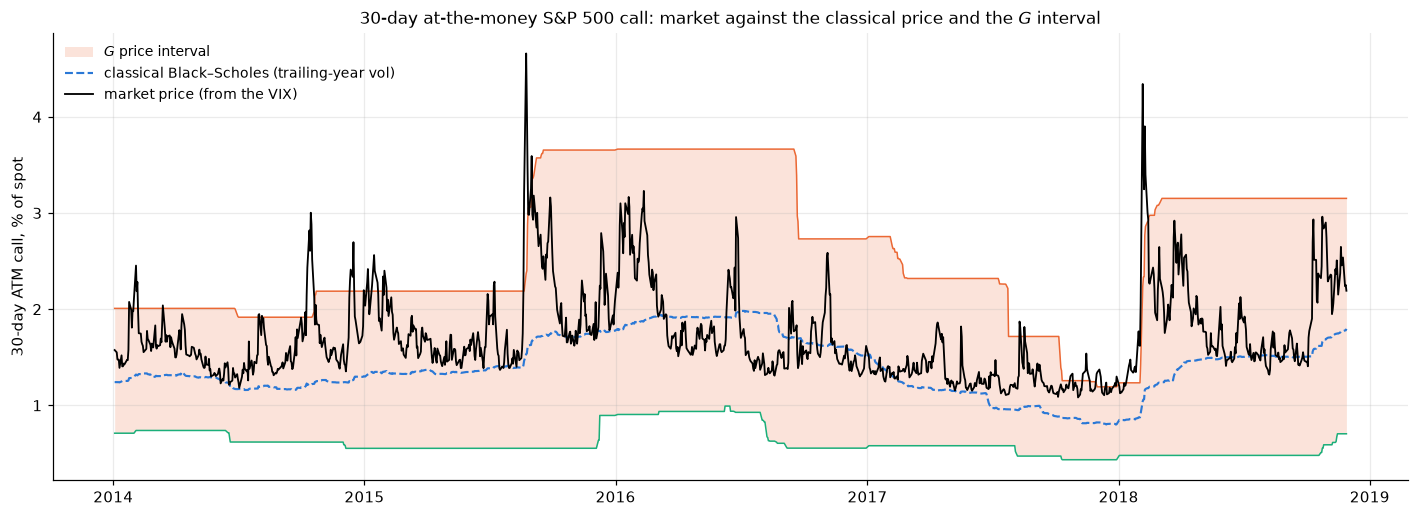

In [15]:
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.fill_between(D.index, D.G_lo, D.G_hi, color=C_UP, alpha=0.18, linewidth=0, label=r"$G$ price interval")
ax.plot(D.index, D.G_hi, color=C_UP, linewidth=1); ax.plot(D.index, D.G_lo, color=C_LO, linewidth=1)
ax.plot(D.index, D.classical, color=C_BS, linewidth=1.4, linestyle="--", label="classical Black–Scholes (trailing-year vol)")
ax.plot(D.index, D.mkt, color="k", linewidth=1.2, label="market price (from the VIX)")
ax.set_ylabel("30-day ATM call, % of spot")
ax.set_title("30-day at-the-money S&P 500 call: market against the classical price and the $G$ interval", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.savefig("figures/gbs_real_prices.pdf", bbox_inches="tight"); plt.show()

In [16]:
def coverage_table(D):
    rows = []
    for name, lo_q, hi_q in [("min – max", 0.0, 1.0), ("5th – 95th pct", 0.05, 0.95),
                             ("10th – 90th pct", 0.10, 0.90), ("25th – 75th pct", 0.25, 0.75)]:
        lo = rv21.rolling(252).quantile(lo_q).reindex(D.index); hi = rv21.rolling(252).quantile(hi_q).reindex(D.index)
        G_lo, G_hi = atm(lo), atm(hi)
        inside_mkt = ((D.mkt >= G_lo) & (D.mkt <= G_hi)).mean()
        inside_fwd = ((D.sig_fwd >= lo) & (D.sig_fwd <= hi)).mean()
        pos = ((D.mkt - G_lo) / (G_hi - G_lo))
        rows.append({"trailing-year interval": name,
                     "mean sigma interval": "[{:.1%}, {:.1%}]".format(lo.mean(), hi.mean()),
                     "mean price interval, % spot": "[{:.2f}, {:.2f}]".format(G_lo.mean(), G_hi.mean()),
                     "market price inside": "{:.0%}".format(inside_mkt),
                     "realised vol inside": "{:.0%}".format(inside_fwd),
                     "market above upper": "{:.0%}".format((D.mkt > G_hi).mean()),
                     "market below lower": "{:.0%}".format((D.mkt < G_lo).mean()),
                     "median position of market in interval": round(float(pos.median()), 2)})
    return pd.DataFrame(rows).set_index("trailing-year interval")

COVER = coverage_table(D)
display(COVER)
ape = ((D.classical - D.mkt).abs() / D.mkt)
print("classical Black–Scholes against the market:  mean |error| {:.1%} of the market price,  "
      "below the market on {:.0%} of days".format(ape.mean(), (D.classical < D.mkt).mean()))
print("market against what was realised ex post:    market above the ex-post fair value on {:.0%} of days "
      "(the variance risk premium)".format((D.mkt > D.fwd_fair).mean()))

,mean sigma interval,"mean price interval, % spot",market price inside,realised vol inside,market above upper,market below lower,median position of market in interval
trailing-year interval,,,,,,,
min – max,"[5.1%, 22.5%]","[0.61, 2.60]",92%,89%,8%,0%,0.56
5th – 95th pct,"[6.1%, 20.5%]","[0.73, 2.37]",87%,81%,13%,0%,0.61
10th – 90th pct,"[6.8%, 17.5%]","[0.80, 2.02]",74%,69%,26%,0%,0.72
25th – 75th pct,"[8.2%, 13.7%]","[0.97, 1.59]",41%,40%,59%,0%,1.12


classical Black–Scholes against the market:  mean |error| 20.2% of the market price,  below the market on 81% of days
market against what was realised ex post:    market above the ex-post fair value on 80% of days (the variance risk premium)


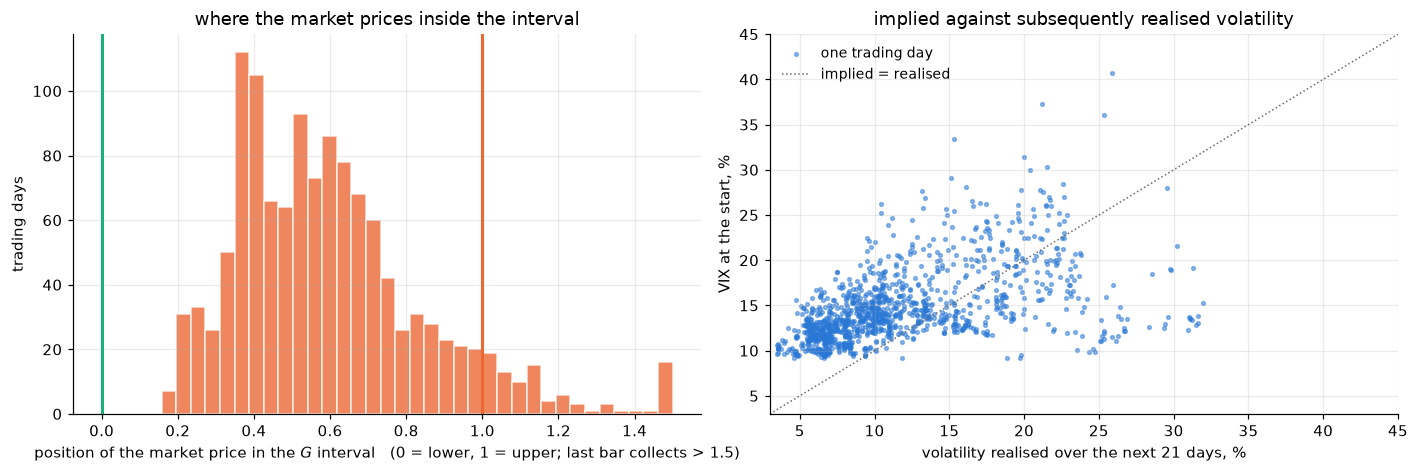

In [17]:
pos = (D.mkt - D.G_lo) / (D.G_hi - D.G_lo)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].hist(pos.clip(-0.25, 1.5), bins=35, color=C_UP, alpha=0.8, edgecolor="white")
axes[0].axvline(0, color=C_LO, linewidth=2); axes[0].axvline(1, color=C_UP, linewidth=2)
axes[0].set_xlabel(r"position of the market price in the $G$ interval   (0 = lower, 1 = upper; last bar collects > 1.5)")
axes[0].set_ylabel("trading days"); axes[0].set_title("where the market prices inside the interval")
axes[1].scatter(D.sig_fwd * 100, D.sig_mkt * 100, s=6, color=C_BS, alpha=0.5, label="one trading day")
lim = [3, 45]; axes[1].plot(lim, lim, color=C_REF, linewidth=1, linestyle=":", label="implied = realised")
axes[1].set_xlabel("volatility realised over the next 21 days, %"); axes[1].set_ylabel("VIX at the start, %")
axes[1].set_xlim(lim); axes[1].set_ylim(lim); axes[1].set_title("implied against subsequently realised volatility")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig("figures/gbs_real_position.pdf", bbox_inches="tight"); plt.show()

In [18]:
# a calm day and a stressed day, call and put, in index points
rows = []
for day in ("2017-10-05", "2018-02-06", "2018-10-11"):
    d = D.loc[pd.Timestamp(day)]
    for kind in ("call", "put"):
        rows.append({"date": day, "option": kind, "S": round(d.S, 1),
                     "sigma classical / market / [lo, hi]": "{:.1%} / {:.1%} / [{:.1%}, {:.1%}]".format(d.sig_class, d.sig_mkt, d.lo, d.hi),
                     "market": round(float(bs_price(d.S, d.S, d.r, T30, d.sig_mkt, kind)), 2),
                     "classical BS": round(float(bs_price(d.S, d.S, d.r, T30, d.sig_class, kind)), 2),
                     "G interval": "[{:.2f}, {:.2f}]".format(bs_price(d.S, d.S, d.r, T30, d.lo, kind), bs_price(d.S, d.S, d.r, T30, d.hi, kind)),
                     "ex-post fair (realised vol)": round(float(bs_price(d.S, d.S, d.r, T30, d.sig_fwd, kind)), 2)})
pd.DataFrame(rows).set_index(["date", "option"])

S sigma classical / market / [lo, hi]  market  \
date       option                                                       
2017-10-05 call    2552.1         7.4% / 9.2% / [3.8%, 14.7%]   27.77   
           put     2552.1         7.4% / 9.2% / [3.8%, 14.7%]   25.88   
2018-02-06 call    2695.1        8.6% / 30.0% / [3.5%, 19.7%]   94.43   
           put     2695.1        8.6% / 30.0% / [3.5%, 19.7%]   90.23   
2018-10-11 call    2728.4       13.1% / 25.0% / [3.5%, 26.9%]   80.02   
           put     2728.4       13.1% / 25.0% / [3.5%, 26.9%]   75.76   

                   classical BS      G interval  ex-post fair (realised vol)  
date       option                                                             
2017-10-05 call           22.56  [12.06, 43.80]                        14.37  
           put            20.67  [10.17, 41.91]                        12.48  
2018-02-06 call           28.61  [12.92, 62.91]                        65.03  
           put            24.40   [8.71, 58.70]                        60.83  
2018-10-11 call           43.10  [13.09, 86.00]                        69.57  
           put            38.85   [8.83, 81.74]                        65.31

## Summary

**Classical against $G$: the mechanics.** The classical Brownian Monte Carlo reproduces the Black–Scholes
closed forms within its confidence intervals, and the Black–Scholes–Barenblatt solver reproduces the
$G$-Brownian closed forms to $2\times10^{-4}$. For a plain call or put the $G$ model gives an interval whose
ends are the classical prices at $\underline\sigma$ and $\bar\sigma$, exactly the convex/concave cases of the
thesis's Section 2.2: with $S_0=100$, $r=5\%$, $T=1$ and $\sigma\in[0.15,0.25]$,

| | classical $\sigma=0.20$ | $G$ lower | $G$ upper | width | width / price |
|---|---|---|---|---|---|
| call $K=100$ | 10.45 | 8.59 | 12.34 | 3.74 | 36% |
| call $K=120$ | 3.25 | 1.66 | 5.03 | 3.37 | 104% |
| put $K=100$ | 5.57 | 3.71 | 7.46 | 3.74 | 67% |
| put $K=80$ | 0.69 | 0.18 | 1.51 | 1.33 | 194% |

The width is vega times $\bar\sigma-\underline\sigma$ to within a few percent, so it is largest in absolute terms at
the money and largest relative to the price in the wings, where the option is almost pure volatility.

**Where $G$ is more than two Black–Scholes prices.** Put–call parity holds for the pair $C-P$, which the
solver prices exactly at $S_0-Ke^{-rT}=4.877$, but the legs priced separately give
$\bar C-\underline P=8.62$ against $\underline C-\bar P=1.13$: a bid–ask spread of 7.49 from volatility
uncertainty alone. For non-convex payoffs the worst-case volatility switches with the sign of gamma, and the
$G$ interval is strictly wider than anything a constant volatility can produce: the butterfly 90/100/110 is
worth 1.84 classically, between 1.50 and 2.36 over all constant $\sigma\in[0.15,0.25]$, and between 0.82 and
3.25 under $G$; a simulation that switches volatility with the solver's $\sigma^*(t,S)$ lands on both ends.

**The thesis's normal model.** With the index given the stock's forward and matched at the money
($\sigma_m=20.99$), the HDD-type formulas (3.22)/(3.24) and their $G$ versions track Black–Scholes closely
near the money and part in the wings, where the lognormal gives more to the call ($K=120$: 3.25 against
2.81) and the normal more to the put ($K=80$: 1.13 against 0.69). The $G$ intervals of the two models have
comparable widths, so the volatility-uncertainty effect is not an artefact of either distribution.

**Real data, S&P 500 2014–2018, 1236 trading days.** Realised 21-day volatility of the index ranged from
3.5% to 85% over 1999–2018, which is the empirical case for not treating $\sigma$ as one number.

| 30-day ATM S&P 500 option | result |
|---|---|
| classical Black–Scholes at trailing-year volatility vs market | mean absolute error 20% of the market price; below the market on 81% of days |
| $G$ interval from the trailing-year min–max of realised volatility | market price inside on **92%** of days, above the upper price on 8%, never below the lower |
| the same interval against the volatility realised over the option's life | inside on **89%** of days |
| narrower intervals (10th–90th percentile) | market inside 74%, realised inside 69% |
| where the market sits in the interval | median position 0.56, i.e. above the middle; the market was above the ex-post fair value on 80% of days |

The classical single-volatility price is systematically below what the market charges, because implied
volatility carries a premium over realised volatility. The $G$ interval, built from nothing but the past
year of realised volatility, contains the market price on nine days out of ten and the ex-post fair price
almost as often. The days it misses are volatility spikes: on 6 February 2018 the VIX jumped to 30% and the
market call was 94 index points against an upper $G$ price of 63, but the volatility actually realised over
the following month priced the option at 65, inside the interval. The market overshot; the interval did not.

**What this does and does not show.** The comparison is at the money and 30 days out, because the market
input available here is the VIX rather than a full option chain; strike-by-strike the picture would add the
volatility smile, which the $G$ model with a single $[\underline\sigma,\bar\sigma]$ does not produce on its own.
The $G$ interval is a no-arbitrage band, not a point forecast: it says what a seller who refuses to bet on
volatility must charge and what a buyer can pay, and on this data the market has lived inside that band.